<a href="https://colab.research.google.com/github/howonJeong/Journey_to_TinyLLAMA/blob/main/Step1_MitDeep/1.7.1_Backpropagation_layers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

이제부터 신경망 구성 계층 하나를 클래스로 구현할 것 : 예를 들어,

시그모이드 함수를 위한 Sigmoid, 행렬 곱을 위한 Affine 등

이번 Bckprop 절에서도 곱셈 덧셈 노드를 계층 단위로 구현하게 됨

In [ ]:
class MulLayer:
  def __init__(self):
    self.x = None
    self.y = None
  #self는 모든 객체가 공유하는 클래스 변수가 아닌 아닌 객체에서 독립적으로 사용될 인스턴스 변수임을 의미
  #인스턴스, 메서드, 클래스..

  def forward(self, x, y):
    self.x = x
    self.y = y
    out = x * y

    return out

  def backward(self, dout):
    dx = dout * self.y
    dy = dout * self.x

    return dx, dy

In [ ]:
apple = 100
apple_num = 2
tax = 1.1

In [ ]:
mul_apple_layer = MulLayer()
mul_tax_layer = MulLayer()

apple_price = mul_apple_layer.forward(apple, apple_num)
price = mul_tax_layer.forward(apple_price, tax)

print(price)

220.00000000000003


In [ ]:
dprice = 1
dapple_price, dtax = mul_tax_layer.backward(dprice)
dapple, dapple_num = mul_apple_layer.backward(dapple_price)

print(dapple, dapple_num, dtax)

2.2 110.00000000000001 200


In [ ]:
class AddLayer:
  def __init__(self):
    pass

  def forward(self, x, y):
    out = x + y
    return out

  def backward(self, dout):
    dx = dout * 1
    dy = dout * 1
    return dx, dy

  #더하기 레이어에서 초기화가 필요없는 이유는?

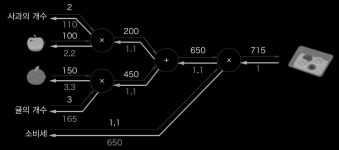

In [ ]:
apple = 100
apple_num = 2
orange = 150
orange_num = 3
tax = 1.1

mul_apple_layer = MulLayer()
mul_orange_layer = MulLayer()
add_apple_orange_layer = AddLayer()
mul_tax_layer = MulLayer()

apple_price = mul_apple_layer.forward(apple, apple_num)
orage_price = mul_orange_layer.forward(orange, orange_num)
all_price = add_apple_orange_layer.forward(apple_price, orage_price)
price = mul_tax_layer.forward(all_price, tax)

dprice = 1
dall_price, dtax = mul_tax_layer.backward(dprice)
dapple_price, dorange_price = add_apple_orange_layer.backward(dall_price)
dorange, dorange_num = mul_orange_layer.backward(dorange_price)
dapple, dapple_num = mul_apple_layer.backward(dapple_price)

print(price)
print(dapple_num, dorange_num, dapple, dorange, dtax)

715.0000000000001
110.00000000000001 165.0 2.2 3.3000000000000003 650


In [ ]:
class Relu:
  def __init__(self):
    self.mask = None

  def forward(self, x):
    self.mask = (x <= 0)
    out = x.copy()
    out[self.mask] = 0

    return out

  def backward(self, dout):
    dout[self.mask] = 0
    #순전파 시 값이 0인 경우는 역전파 때 0이 되어야 - 순전파 때 만들어놓은 마스크 활용하기
    dx = dout

    return dx

In [ ]:
#시그모이드 역전파는 순전파 출력만으로 계산 가능

In [ ]:
class Sigmoid:
  def __init__(self):
    self.out = None

  def forward(self, x):
    out = 1 / (1 + np.exp(-x))
    self.out = out

    return out

  def backward(self, dout):
    dx = dout / (1 - self.out) * self.out

    return dx

Affine 계층 설계

Caution : (2,) 행렬은 $2$ X $1$이 아니라 열, 행 벡터 될 수 있는 2차원 벡터임

> 왜 편미분 결과는 미분 당하는 행렬(종속변수)의 차원 상관없이 미분하는 행렬(독립변수)의 차원을 따라가는가?

* $Y$ 행렬 안에 원소가 10개 있다면, 그 10개 각각이 $L$에 주는  영향력도 당연히 10개가 나와야 하기 때문이다.

> 여기서 "편미분 결과"의 정제된 표현은?

* 로스에 대한 손실함수의 그라디언트



In [ ]:
import numpy as np

X_dot_W = np.array([[0,0,0], [10,10,10]]) #입력 두 개의, "알 수 없는 차원의", 가중치 2개를 곱한, 그 결과
B = np.array([1,2,3])

X_dot_W + B #브로드 캐스팅

array([[ 1,  2,  3],
       [11, 12, 13]])

역전파 시?


In [ ]:
dY = np.array([[1,2,3], [4,5,6]])
dB = np.sum(dY, axis=0)

dB axis = 0 (y축)으로 더하기 = 미분의 선형결합

In [ ]:
print(dY, dB)

[[1 2 3]
 [4 5 6]] [5 7 9]


In [ ]:
class Affine:
  def __init__(self, W, b):
    self.W = W
    self.b = b
    self.x = None
    self.dW = None
    self.db = None

  def forward(self, x):
    self.x = x
    out = np.dot(x, self.W) + self.b

    return out

  def backward(self, dout):
    dx = np.dot(dout, self.W.T)
    self.dW = np.dot(self.x.T, dout)
    self.db = np.sum(dout, axis = 0)

    return dx

In [ ]:
def softmax(x):
    if x.ndim == 2:
        x = x.T
        x = x - np.max(x, axis=0)
        y = np.exp(x) / np.sum(np.exp(x), axis=0)
        return y.T

    x = x - np.max(x) # 오버플로 대책
    return np.exp(x) / np.sum(np.exp(x))

def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    if t.size == y.size:
        t = t.argmax(axis=1)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

In [ ]:
class SoftmaxWithLoss:
  def __init__(self):
    self.loss = None
    self.y = None
    self.t = None #정답 레이블

  def forward(self, x, t):
    self.t = t
    self.y = softmax(x)
    self.loss = cross_entropy_error(self.y, self.t)

    return self.loss

  def backward(self, dout=1):
    batch_size = self.t.shape[0]
    dx = (self.y - self.t) / batch_size

    return dx